```{toctree}
:maxdepth: 3
:caption: Contents:

# Walkthrough Example - Temporal Analysis

```{hint}
Before using the `WaveTemporalAnalyzer` class, make sure you have the necessary data and dependencies installed. This example assumes you have time series data from an AQUAlogger and a RBR device.

Users are referred to the [installation instructions](https://oceanicos-dev-org.readthedocs.io/en/latest/installing.html) page for a installation guide of the `oceanicospy` package and its dependencies.
```

# Importing required modules and subpackages

In [ ]:
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np

The subpackage temporal will deal with the temporal analysis of the sea surface elevation data. AQUAlogger and RBR classes are also imported to load the sensor data.

In [2]:
from oceanicospy.observations import pressure_sensors
from oceanicospy.analysis import temporal
from oceanicospy.plots import *

/scratchsan/medellin/.conda/envs/oceanicospy-dev-jtorresto/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Pressure data

The metadata of the deployment for each sensor is presented in a dictionary format, while the data files are passed as paths (strings).

In [3]:
measurement_pressure_sensors_paths = ['../../data/observations/AQUAlogger/',
                                      '../../data/observations/RBR/']

sampling_AQ = dict(anchoring_depth=1,
                   sensor_height=0.2,
                   sampling_freq=1,
                   burst_length_s=2048,
                   start_time=datetime(2025,5,9,10,0,0),
                   end_time=datetime(2025,5,19,18,0,0))
sampling_RBR = dict(anchoring_depth=1,
                    sensor_height=0.2,
                    sampling_freq=2,
                    burst_length_s=7200,
                    start_time=datetime(2025,5,9,10,0,0),
                    end_time=datetime(2025,5,19,18,0,0))

Methods from the observations subpackage are used to load the raw pressure data from the sensors. The data is then cleaned and prepared for the temporal analysis. For further information about how to upload the sensor data using **oceanicospy**, please refer to the [data loading example](https://oceanicospy-dev-org.readthedocs.io/en/latest/observations/reading_field_data.html).

In [4]:
sampling_data = [sampling_AQ,sampling_RBR]
metadata_list=['AQ','RBR']
dict_raw_measurements = dict()
dict_clean_measurements = dict()

for idx,measurement_path in enumerate(measurement_pressure_sensors_paths):
    if 'AQ' in measurement_path:
        object_device = pressure_sensors.AQUAlogger(measurement_path, sampling_data[idx], 
                                                    filename='AQUAlogger_520PT5.csv')
    else:
        object_device = pressure_sensors.RBR(measurement_path,sampling_data[idx])

    raw_data = object_device.get_raw_records()
    clean_data = object_device.get_clean_records()
    dict_raw_measurements[metadata_list[idx]] = raw_data
    dict_clean_measurements[metadata_list[idx]] = clean_data

A quick look at each key (sensor) in the dictionary shows the measurements as pandas DataFrames.

In [5]:
dict_clean_measurements['AQ'].head()

,pressure[bar],depth[m],depth_aux[m],burstId,eta[m]
date,,,,,
2025-05-09 10:00:00,1.245722,3.136509,2.307327,1,0.052596
2025-05-09 10:00:01,1.244709,3.124966,2.297273,1,0.041052
2025-05-09 10:00:02,1.237181,3.039040,2.222556,1,-0.044874
2025-05-09 10:00:03,1.243695,3.113418,2.287209,1,0.029503
2025-05-09 10:00:04,1.253249,3.222086,2.382034,1,0.138170


In [6]:
dict_clean_measurements['RBR'].head()

,pressure[bar],depth[m],burstId,eta[m]
date,,,,
2025-05-09 10:00:00.000,1.241829,2.267149,1,0.117985
2025-05-09 10:00:00.500,1.239702,2.246051,1,0.096886
2025-05-09 10:00:01.000,1.235314,2.202530,1,0.053365
2025-05-09 10:00:01.500,1.233978,2.189276,1,0.040110
2025-05-09 10:00:02.000,1.234466,2.194119,1,0.044954


# Using the `WaveTemporalAnalyzer` class

First, we need to instanciate the `WaveTemporalAnalyzer` class, which will allow us to make the temporal analysis for the sensor data (whether be pressure, sea surface elevation, etc.). We need to provide the measured signal and the sampling data as arguments.

`WaveTemporalAnalyzer` will look for measurement signal with a column named `eta[m]`, which is the standard name for the sea surface elevation in **oceanicospy**. If the column name is different, it can be specified as an argument when instanciating the class.

## Zero upcrossing method

In [7]:
wave_params_dfs = dict()
for idx,metadata in enumerate(metadata_list):
    TemporalAnalyzer = temporal.WaveTemporalAnalyzer(dict_clean_measurements[metadata],
                                                     sampling_data[idx])
    print(f"The {metadata} sensor data is being analyzed using {type(TemporalAnalyzer)}")
    wave_params_dfs[metadata_list[idx]] = TemporalAnalyzer.compute_params_from_zero_upcrossing()

The AQ sensor data is being analyzed using <class 'oceanicospy.analysis.temporal.WaveTemporalAnalyzer'>
The following bursts have been removed due to incorrect length: [125]
The RBR sensor data is being analyzed using <class 'oceanicospy.analysis.temporal.WaveTemporalAnalyzer'>
The following bursts have been removed due to incorrect length: [249]


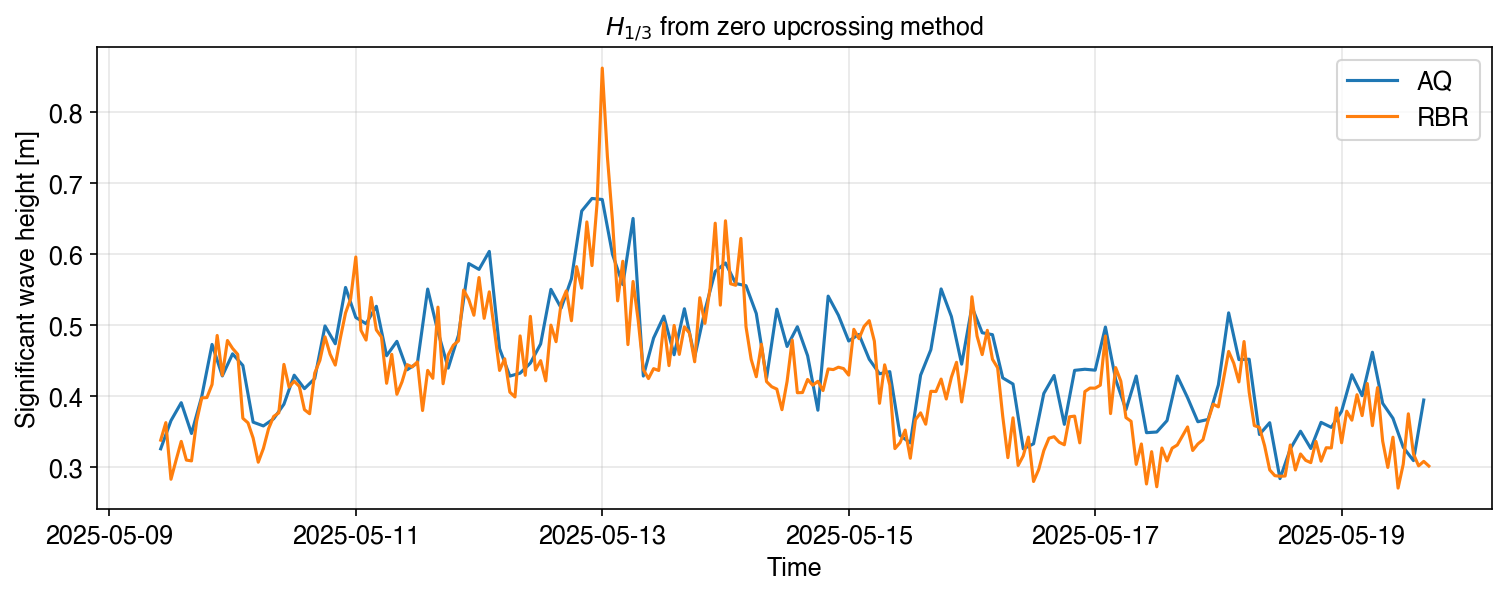

In [8]:
fig,ax = plt.subplots(1,1,figsize=(12,4))

ax.plot(wave_params_dfs['AQ']['H1/3'],label='AQ')
ax.plot(wave_params_dfs['RBR']['H1/3'],label='RBR')
ax.set(ylabel='Significant wave height [m]',xlabel='Time',title='$H_{1/3}$ from zero upcrossing method')
ax.grid(True,alpha=0.3)
ax.legend()
plt.show()

# Empirical mode decomposition (EMD) method

We can also use the EMD method to decompose the sea surface elevation signal into its intrinsic mode functions (IMFs). This can be useful to analyze the different frequency components of the signal.

The shape of the resulting array of IMFs is `(n_bursts, maximum_IMFs, burst_length_s)`, where `n_bursts` is the number of bursts in the measured signal, `maximum_IMFs` is the maximum number of IMFs specified as an argument, and `burst_length_s` is the length of each burst in seconds.

All the required arguments for the EMD method are specified as arguments in the `decompose_into_IMFs_for_bursts` method. The `EMD_type` argument can be set to either 'EMD', 'EEMD' and 'CEEMDAN', depending on the desired decomposition method. The `number_ensembles` and `amplitude_noise_std` arguments are only relevant for the `EEMD` and `CEEMDAN` methods, and they specify the number of ensembles and the standard deviation of the added noise, respectively.

In [9]:
TemporalAnalyzer_AQ = temporal.WaveTemporalAnalyzer(dict_clean_measurements['AQ'],
                                                    sampling_data[0])
IMFs_burst_AQ = TemporalAnalyzer_AQ.decompose_into_IMFs_for_bursts(EMD_type='EEMD',
                                                                   maximum_IMFs=5,
                                                                   number_ensembles=100,
                                                                   amplitude_noise_std=0.3)

The following bursts have been removed due to incorrect length: [125]


All the 5 IMFs can be plotted for a given burst to visualize the different frequency components of the signal. In this case, the 10th burst of the AQUAlogger sensor data is used as an example.

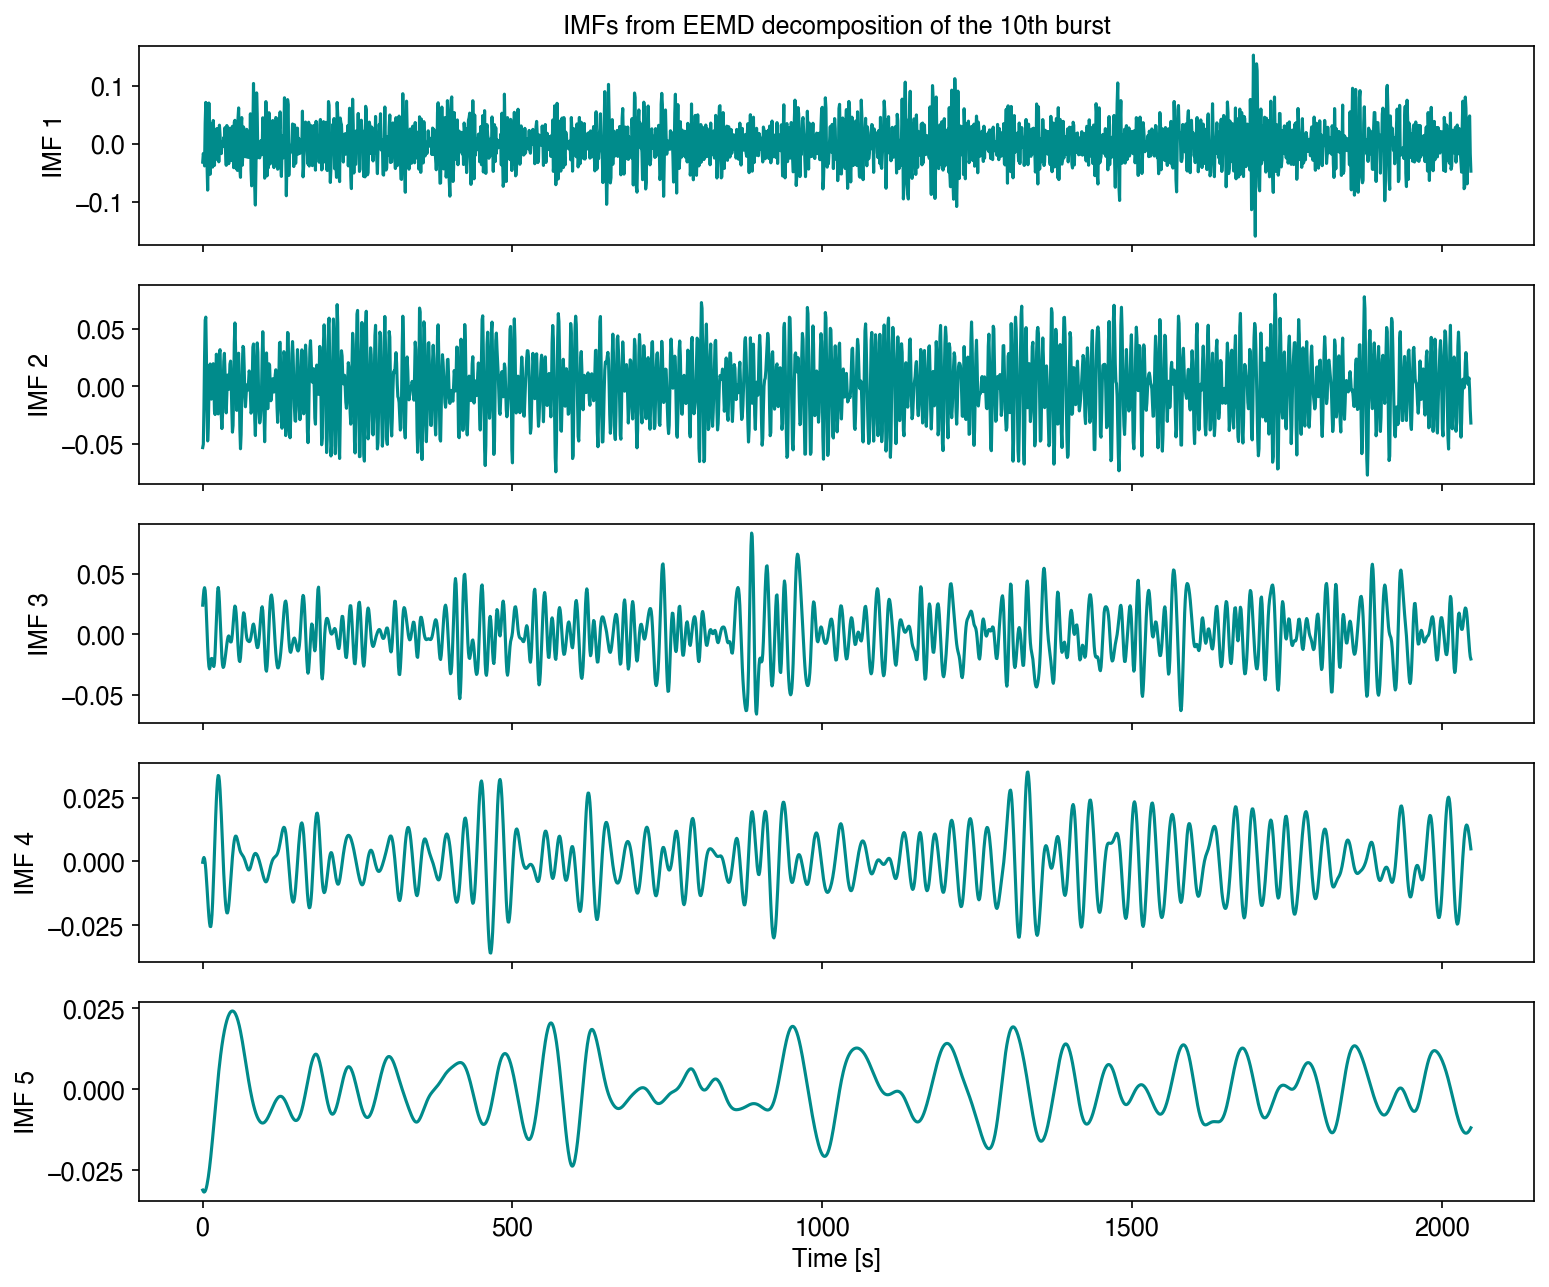

In [10]:
fig,ax = plt.subplots(5,1,figsize=(12,10),sharex=True)
for i in range(5):
    ax[i].plot(IMFs_burst_AQ[9,i,:],color='darkcyan')
    ax[i].set(ylabel=f'IMF {i+1}')
ax[-1].set(xlabel='Time [s]')
ax[0].set_title('IMFs from EEMD decomposition of the 10th burst')
plt.show()

Those IMFs obtained from the function can be later used in combination with the spectral analysis to obtain the frequency content of each IMF, which can be useful to analyze the different frequency components of the signal.

Other example can be done for the 'EMD' method, which does not require the `number_ensembles` and `amplitude_noise_std` arguments, and it can be used to decompose the signal without adding noise. In this case, the maximum number of IMFs is set to 7, and the resulting IMFs can be plotted in a similar way as shown above.

In [11]:
TemporalAnalyzer_RBR= temporal.WaveTemporalAnalyzer(dict_clean_measurements['RBR'],sampling_data[1])
IMFs_burst_RBR = TemporalAnalyzer_RBR.decompose_into_IMFs_for_bursts(EMD_type='EMD',maximum_IMFs=7)

The following bursts have been removed due to incorrect length: [249]


The 10th burst of the RBR sensor data is used as an example in this case and all the IMFs are plotted to visualize the different frequency components of the signal.

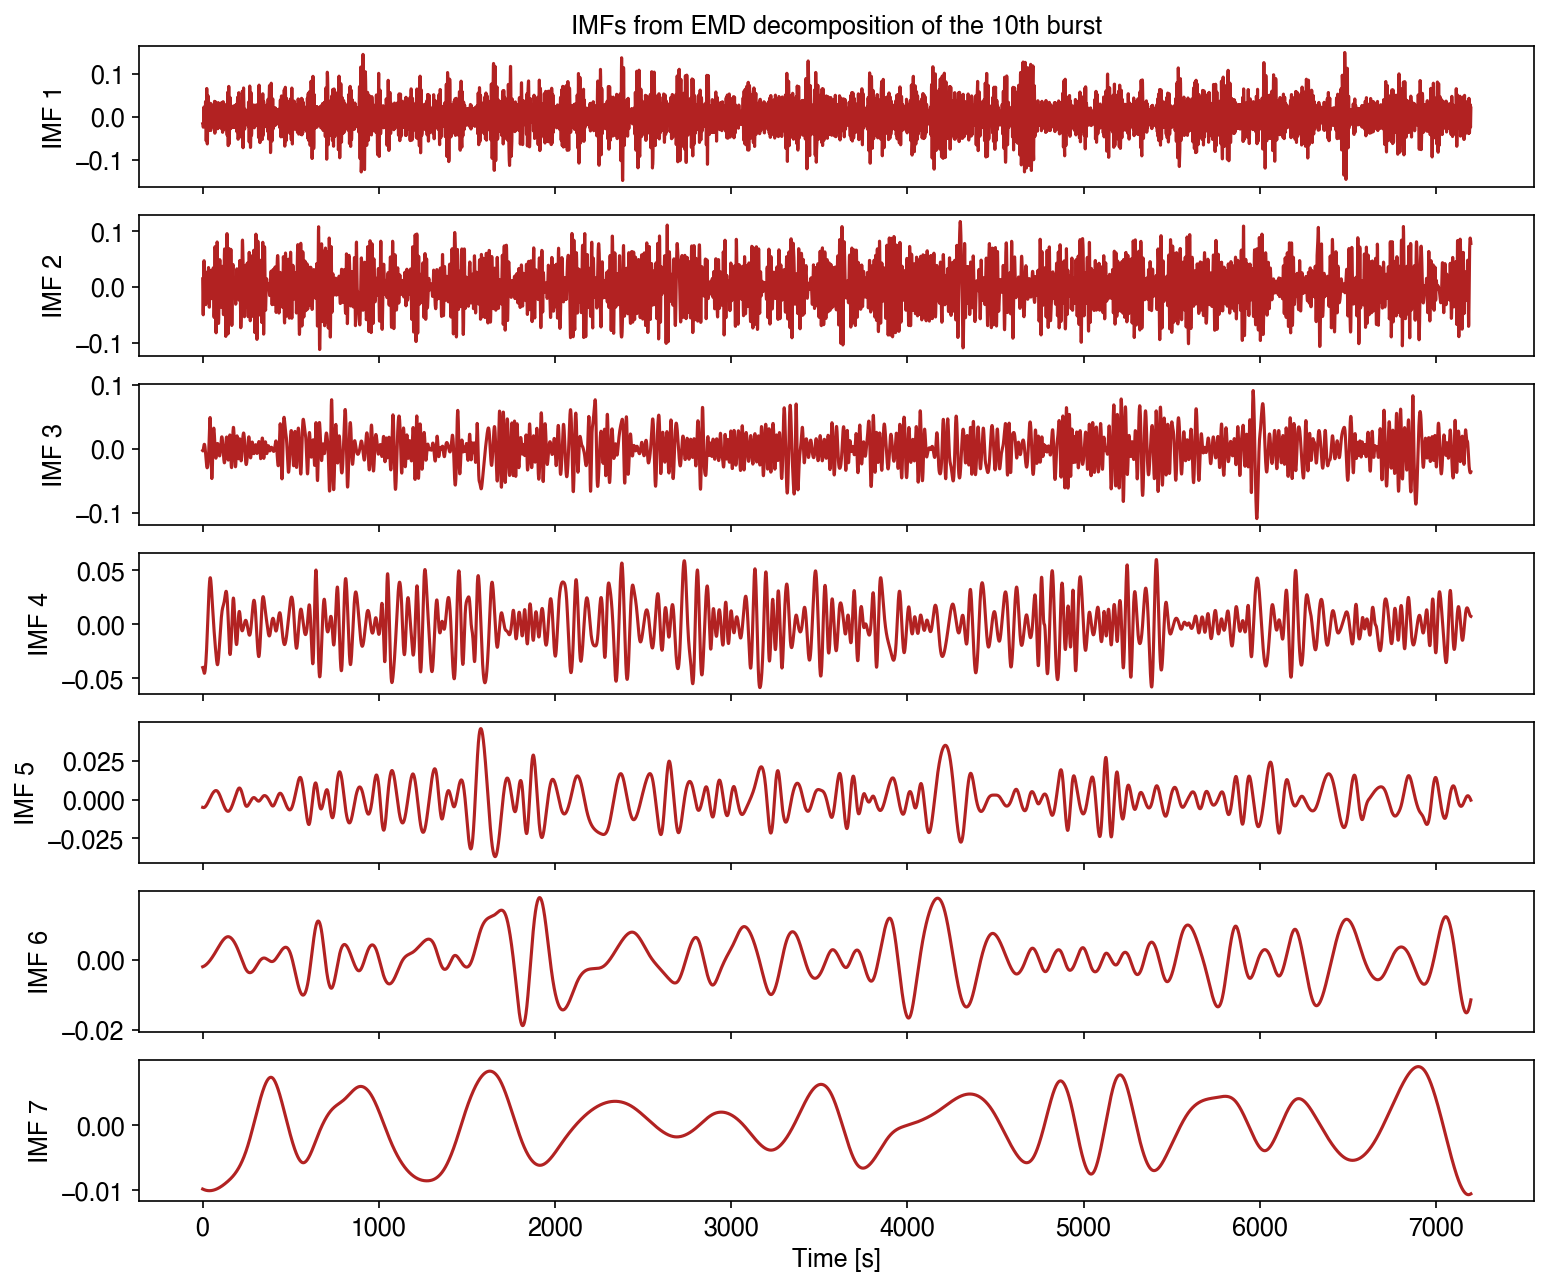

In [12]:
fig,ax = plt.subplots(7,1,figsize=(12,10),sharex=True)
for i in range(7):
    ax[i].plot(IMFs_burst_RBR[9,i,:],color='firebrick')
    ax[i].set(ylabel=f'IMF {i+1}')
ax[-1].set(xlabel='Time [s]')
ax[0].set_title('IMFs from EMD decomposition of the 10th burst')
plt.show()